### Assignment10-VB

In [1]:
# Importing basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [2]:
#Loading the dataset
df = pd.read_csv('knn_assignment_data')

In [4]:
# Display summary statistics(count, mean, std, min, max) - for all numeric features in the dataset.
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
XVPM,1000.0,1055.071157,370.980193,21.17,767.413366,1045.904805,1326.065178,2117.0
GWYH,1000.0,991.851567,392.278890,21.72,694.859326,978.355081,1275.528770,2172.0
TRAT,1000.0,1529.373525,640.286092,31.80,1062.600806,1522.507269,1991.128626,3180.0
TLLZ,1000.0,495.107156,142.789188,8.45,401.788135,500.197421,600.525709,845.0
IGGA,1000.0,940.590072,345.923136,17.93,700.763295,939.348662,1182.578166,1793.0
HYKR,1000.0,1550.637455,493.491988,27.93,1219.267077,1564.996551,1891.937040,2793.0
EDFS,1000.0,1561.003252,598.608517,31.96,1132.097865,1565.882879,1981.739411,3196.0
GUUB,1000.0,561.346117,247.357552,13.52,381.704293,540.420379,725.762027,1352.0
MGJM,1000.0,1089.067338,402.666953,23.21,801.849802,1099.087954,1369.923665,2321.0
JHZC,1000.0,1452.521629,568.132005,30.89,1059.499689,1441.554053,1864.405512,3089.0


In [5]:
#showing the first five rows
df.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   XVPM          1000 non-null   float64
 1   GWYH          1000 non-null   float64
 2   TRAT          1000 non-null   float64
 3   TLLZ          1000 non-null   float64
 4   IGGA          1000 non-null   float64
 5   HYKR          1000 non-null   float64
 6   EDFS          1000 non-null   float64
 7   GUUB          1000 non-null   float64
 8   MGJM          1000 non-null   float64
 9   JHZC          1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


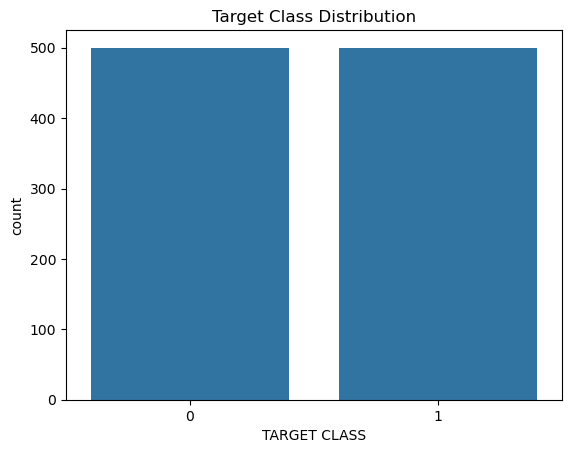

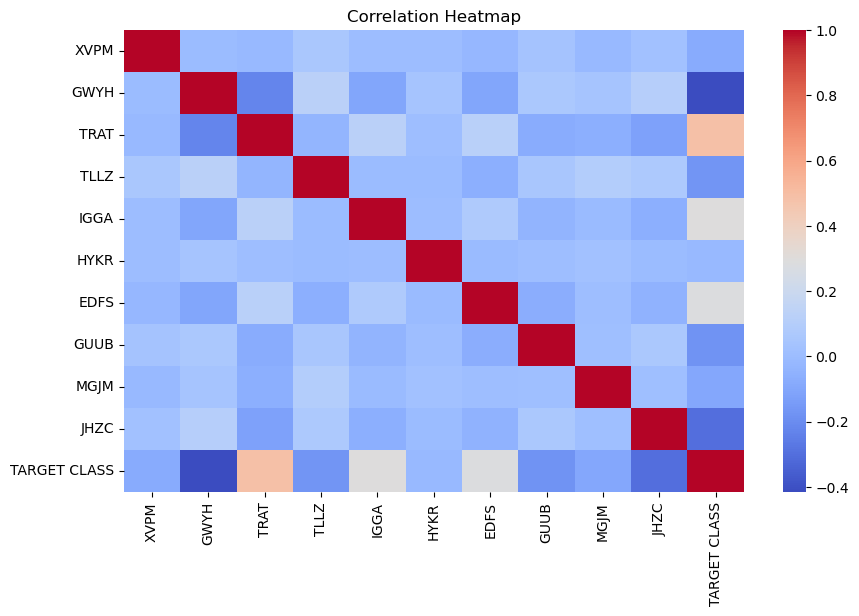

In [6]:
# Basic information about the dataset
df.info()

# Checking for missing values
df.isnull().sum()

# Basic statistics
df.describe()

# Class distribution
sns.countplot(x='TARGET CLASS', data=df)
plt.title('Target Class Distribution')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
#Display plot
plt.show()


From the above table we can see there are no missing values in the dataset. The target variable(TARGET CLASS) is binary(0 or 1).Numerical features show moderate correlation,which is suitable for KNN.

## Splitting Data into Training and Testing Sets

In [7]:
# Defining X (features) and y (target)
X = df.drop('TARGET CLASS', axis=1)
y = df['TARGET CLASS']

# Splitting into train and test (70-30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardizing the features using standard scaler 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Features are scaled using StandardScaler to make sure all the variables contribute equally to the distance metric used in KNN.

## Fitting a KNN Model with K=1

In [8]:
# Training a KNN model with K=1, makes predictions on the test set,
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

pred = knn.predict(X_test)

# Evaluating model
# print performance metrics (confusion matrix, classification report, and accuracy score).
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))
print("Accuracy for K=1:", accuracy_score(y_test, pred))


[[109  37]
 [ 46 108]]
              precision    recall  f1-score   support

           0       0.70      0.75      0.72       146
           1       0.74      0.70      0.72       154

    accuracy                           0.72       300
   macro avg       0.72      0.72      0.72       300
weighted avg       0.72      0.72      0.72       300

Accuracy for K=1: 0.7233333333333334


The model with K=1 tends to overfit training data because it uses the closest single neighbor for prediction. Evaluation metrics like (precision, recall, F1-score) give initial insights into performance.

## Train Multiple KNN Models (K=1 to 50)

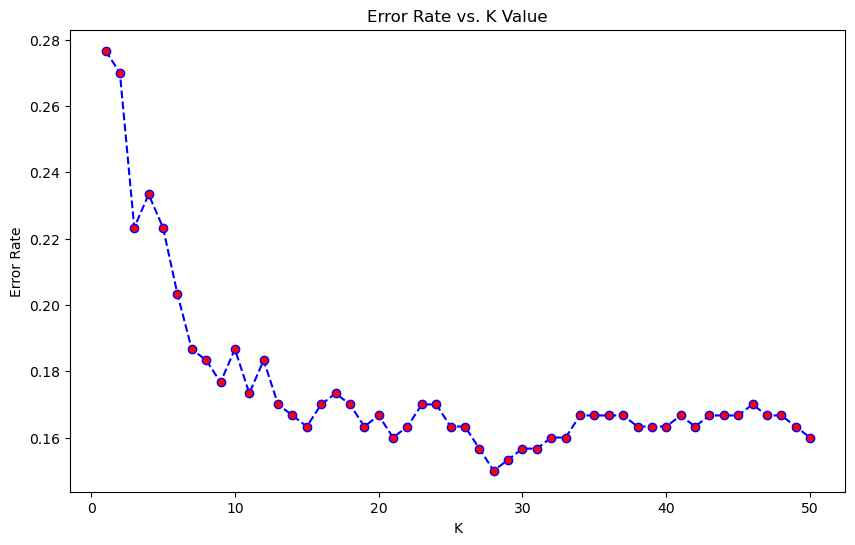

In [17]:
error_rate = []
# Looping through K values
# For each K value, calculating the mean error rate(proportion of incorrect predictions) and store it in the error_rate list to identify the K with the lowest error.
for k in range(1, 51):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rate.append(np.mean(pred_k != y_test))

# Plotting the error rate vs K
plt.figure(figsize=(10,6))
plt.plot(range(1,51), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=6)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
#Display Plot
plt.show()


The graph shows how the model performance changes as K value increases. The ideal K is where the error rate starts to falls down (lowest point before rising again). so as per graph the ideal K value is 28.

## Final Model with Best K

In [44]:
# Finding the K value with the lowest error rate and setting it as the best K.
best_k = error_rate.index(min(error_rate))+1
print("Best K is", best_k)
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)
# Training the final KNN model using this K, make predictions.
final_pred = final_knn.predict(X_test)
# printing the confusion matrix, classification report, and final accuracy.
print("\n Confusion Matrix \n\n",confusion_matrix(y_test, final_pred))
print("\n Classification Report \n\n",classification_report(y_test, final_pred))
print("\n Final Model Accuracy:", accuracy_score(y_test, final_pred))


Best K is 28

 Confusion Matrix 

 [[128  18]
 [ 27 127]]

 Classification Report 

               precision    recall  f1-score   support

           0       0.83      0.88      0.85       146
           1       0.88      0.82      0.85       154

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300


 Final Model Accuracy: 0.85


### Summary of Model Evaluation:

Class 0:
Precision=0.83, 83% of predicted 0s are correct.
Recall=0.88, Model correctly identified 88% of actual class 0s.
F1-score=0.85, Balanced accuracy between precision and recall.

Class 1:
Precision=0.88, 88% of predicted 1s are correct.
Recall=0.82, Model correctly identified 82% of actual class 1s.
F1-score=0.85, Balanced accuracy between precision and recall.

Slightly better precision means the model is more confident when predicting class 1.

This shows the model correctly classified 85% of the test data.

The final KNN model with K = 28 has a balance among bias and variance, thereby minimizing the overfitting while by maintaining the strong accuracy on test data.
The balanced precision and recall shows that the model performs well for both classes without major bias toward one.